# Laboratorio 13: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar patrones binarios y recuperar una imagen original a partir de una versión perturbada con ruido.

La idea central es modelar la dinámica de la red como un proceso de minimización de energía, de modo que los patrones almacenados se conviertan en atractores del sistema.

## Contexto matemático

En una red de Hopfield, cada neurona toma valores binarios en el conjunto $\{-1, 1\}$. Si almacenamos $P$ patrones $\xi^\mu$, la matriz de pesos se define por la regla de Hebb:

$$
w_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu,
$$

con $w_{ii}=0$ para evitar auto-conexiones.

El campo local de la neurona $i$ es

$$
h_i = \sum_j w_{ij} s_j,
$$

y la regla de actualización determinista es

$$
s_i \leftarrow \mathrm{sign}(h_i).
$$

La energía total de la red está dada por

$$
E(s) = -\frac{1}{2} s^T W s,
$$

y durante la recuperación asincrónica esta energía debe disminuir o mantenerse estable hasta llegar a un atractor.

## Librerías

En esta práctica usaremos `numpy` para el cálculo numérico, `matplotlib` para las gráficas y algunas utilidades de `skimage` para cargar y redimensionar la imagen de ejemplo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

## Funciones auxiliares

Primero definimos las funciones básicas para trabajar con la red de Hopfield: vectorización de una imagen, construcción de la matriz de pesos, cálculo de la energía, adición de ruido y recuperación asincrónica aleatoria.

In [2]:
def imagen_a_vector(img_binaria):
    return img_binaria.reshape(-1)

def vector_a_imagen(vector, forma):
    return vector.reshape(forma)

def matriz_pesos_hopfield(patrones):
    patrones = np.asarray(patrones, dtype=float)
    if patrones.ndim == 1:
        patrones = patrones[np.newaxis, :]

    numero_patrones, numero_neuronas = patrones.shape
    W = (patrones.T @ patrones) / numero_neuronas
    np.fill_diagonal(W, 0.0)
    return W

def campo_local(W, s, i):
    return float(W[i] @ s)

def actualizar_neurona(W, s, i):
    h_i = campo_local(W, s, i)
    return 1 if h_i >= 0 else -1

def energia_red(W, s):
    return float(-0.5 * s @ W @ s)

def agregar_ruido(s, frac=0.1, seed=None):
    rng = np.random.default_rng(seed)
    s_ruido = s.copy()
    n_flip = max(1, int(frac * len(s_ruido)))
    indices = rng.choice(len(s_ruido), size=n_flip, replace=False)
    s_ruido[indices] *= -1
    return s_ruido, indices

def recuperar_hopfield(W, s_inicial, max_epocas=30, seed=None):
    rng = np.random.default_rng(seed)
    s = s_inicial.copy()
    historia_energia = [energia_red(W, s)]

    for _ in range(max_epocas):
        cambios = 0
        for i in rng.permutation(len(s)):
            nuevo = actualizar_neurona(W, s, i)
            if nuevo != s[i]:
                s[i] = nuevo
                cambios += 1
        historia_energia.append(energia_red(W, s))
        if cambios == 0:
            break

    return s, np.array(historia_energia)

## Imagen de trabajo

Usaremos la imagen `camera` de `skimage`. Luego la reducimos para que la red tenga menos neuronas y binarizamos la intensidad usando un umbral global. El resultado será un patrón en $\{-1, 1\}$ listo para ser almacenado por la red.

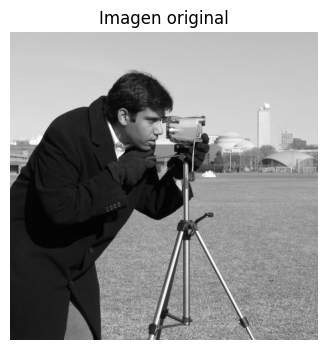

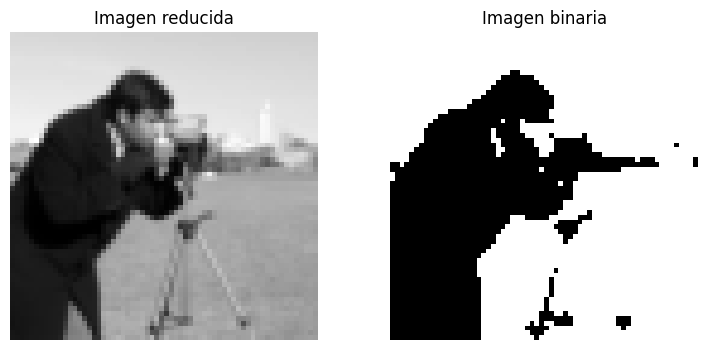

Número de neuronas: 4096


In [3]:
img = data.camera()

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

n, m = 64, 64
img_pequena = resize(img, (n, m), anti_aliasing=True)
umbral = img_pequena.mean()
img_binaria = np.where(img_pequena >= umbral, 1, -1)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_pequena, cmap="gray")
ax[0].set_title("Imagen reducida")
ax[0].axis("off")

ax[1].imshow(img_binaria, cmap="gray", vmin=-1, vmax=1)
ax[1].set_title("Imagen binaria")
ax[1].axis("off")
plt.show()

patron = imagen_a_vector(img_binaria)
print("Número de neuronas:", patron.size)

## Aprendizaje de un patrón

En el caso más simple, almacenamos un solo patrón. Esto permite ver de forma clara cómo la red construye un mínimo de energía alrededor de la imagen binaria original.

In [5]:
W = matriz_pesos_hopfield(patron)

energia_original = energia_red(W, patron)
print(f"Energía del patrón original: {energia_original:.6f}")
print("Matriz de pesos construida con éxito.")

Energía del patrón original: -2047.500000
Matriz de pesos construida con éxito.


## Perturbación y recuperación

Ahora introducimos ruido invirtiendo una fracción de los píxeles. Después ejecutamos la dinámica asincrónica de Hopfield hasta que la imagen deje de cambiar o se alcance un número máximo de épocas.

Píxeles invertidos: 491
Similitud patrón vs. ruido: 0.8801
Similitud patrón vs. recuperado: 1.0000
Energía inicial: -1183.215332
Energía final:   -2047.500000


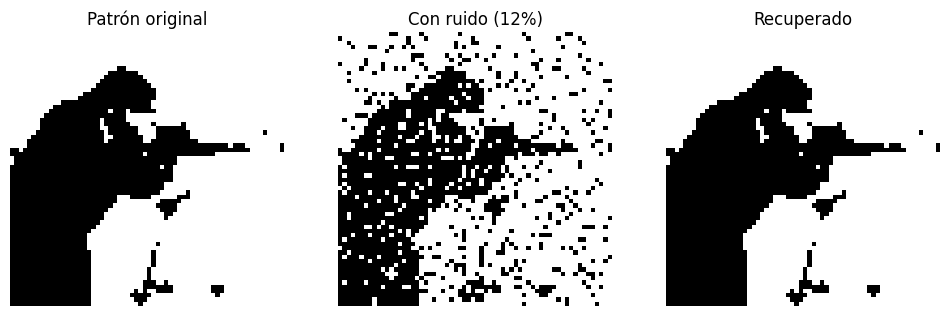

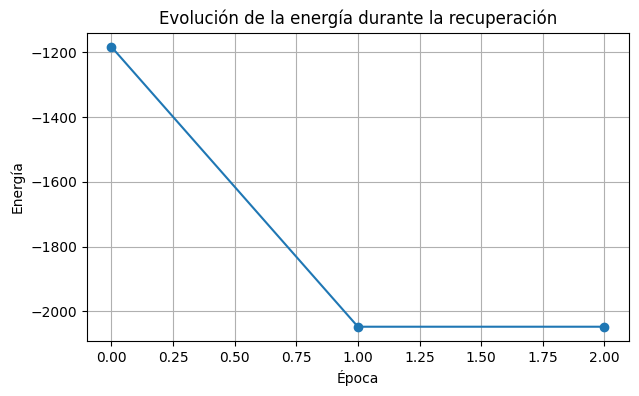

In [6]:
frac_ruido = 0.12
s_ruido, indices_ruido = agregar_ruido(patron, frac=frac_ruido, seed=7)
s_recuperado, historia_energia = recuperar_hopfield(W, s_ruido, max_epocas=25, seed=7)

similitud_entrada = np.mean(s_ruido == patron)
similitud_final = np.mean(s_recuperado == patron)

print(f"Píxeles invertidos: {len(indices_ruido)}")
print(f"Similitud patrón vs. ruido: {similitud_entrada:.4f}")
print(f"Similitud patrón vs. recuperado: {similitud_final:.4f}")
print(f"Energía inicial: {historia_energia[0]:.6f}")
print(f"Energía final:   {historia_energia[-1]:.6f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(vector_a_imagen(patron, (n, m)), cmap="gray", vmin=-1, vmax=1)
ax[0].set_title("Patrón original")
ax[0].axis("off")

ax[1].imshow(vector_a_imagen(s_ruido, (n, m)), cmap="gray", vmin=-1, vmax=1)
ax[1].set_title(f"Con ruido ({frac_ruido*100:.0f}%)")
ax[1].axis("off")

ax[2].imshow(vector_a_imagen(s_recuperado, (n, m)), cmap="gray", vmin=-1, vmax=1)
ax[2].set_title("Recuperado")
ax[2].axis("off")

plt.show()

plt.figure(figsize=(7, 4))
plt.plot(historia_energia, marker="o")
plt.xlabel("Época")
plt.ylabel("Energía")
plt.title("Evolución de la energía durante la recuperación")
plt.show()

## Interpretación del experimento

La recuperación exitosa se interpreta como una convergencia hacia un mínimo local de la energía. En este caso, como solo se almacena un patrón, la red tiene un atractor dominante y la imagen recuperada debe acercarse mucho al patrón original.

El gráfico de energía permite verificar el comportamiento esperado: la dinámica asincrónica no debe aumentar la energía global de forma sostenida. Si la energía cae y luego se estabiliza, la red alcanzó un estado estable.

## Extensión: varios patrones simples

Para ilustrar la memoria asociativa con más de un patrón, construimos tres imágenes binarias sintéticas: una franja horizontal, una franja vertical y un tablero de ajedrez. Luego entrenamos una red de Hopfield con esos tres patrones y probamos la recuperación de uno de ellos perturbado con ruido.

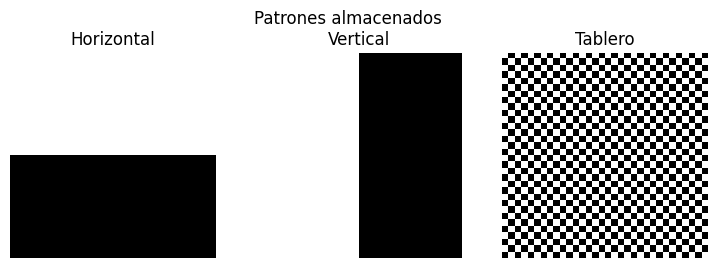

Similitud entre el patrón objetivo y el recuperado: 1.0000


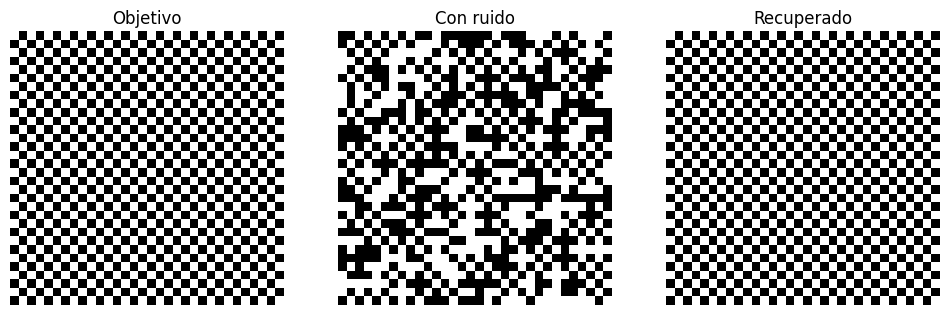

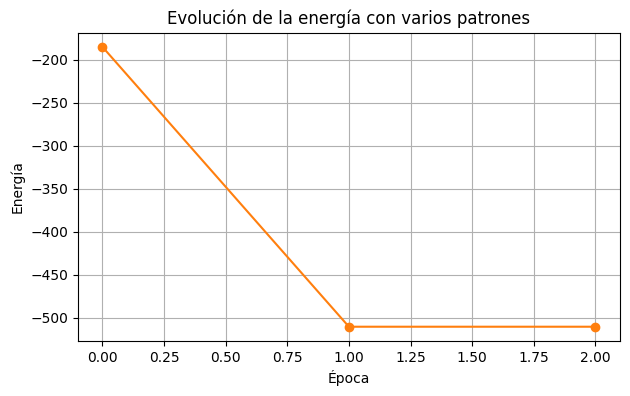

In [7]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[: n // 2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, : m // 2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

h, v, d = patrones_balanceados(32, 32)
patrones = np.array([imagen_a_vector(h), imagen_a_vector(v), imagen_a_vector(d)])
W_multi = matriz_pesos_hopfield(patrones)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for eje, patron_img, titulo in zip(ax, [h, v, d], ["Horizontal", "Vertical", "Tablero"]):
    eje.imshow(patron_img, cmap="gray", vmin=-1, vmax=1)
    eje.set_title(titulo)
    eje.axis("off")
plt.suptitle("Patrones almacenados")
plt.show()

patron_objetivo = imagen_a_vector(d)
patron_ruidoso, _ = agregar_ruido(patron_objetivo, frac=0.20, seed=21)
patron_recuperado, energia_multi = recuperar_hopfield(W_multi, patron_ruidoso, max_epocas=20, seed=21)

similitud_multi = np.mean(patron_recuperado == patron_objetivo)
print(f"Similitud entre el patrón objetivo y el recuperado: {similitud_multi:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(vector_a_imagen(patron_objetivo, (32, 32)), cmap="gray", vmin=-1, vmax=1)
ax[0].set_title("Objetivo")
ax[0].axis("off")

ax[1].imshow(vector_a_imagen(patron_ruidoso, (32, 32)), cmap="gray", vmin=-1, vmax=1)
ax[1].set_title("Con ruido")
ax[1].axis("off")

ax[2].imshow(vector_a_imagen(patron_recuperado, (32, 32)), cmap="gray", vmin=-1, vmax=1)
ax[2].set_title("Recuperado")
ax[2].axis("off")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(energia_multi, marker="o", color="tab:orange")
plt.xlabel("Época")
plt.ylabel("Energía")
plt.title("Evolución de la energía con varios patrones")
plt.show()

## Discusión final

La red de Hopfield funciona como un sistema que convierte patrones almacenados en mínimos de energía. Cuando se introduce ruido, la dinámica asincrónica explora el espacio de estados hasta acercarse al atractor más cercano.

En el caso de un solo patrón, la recuperación suele ser muy estable porque ese estado domina claramente la dinámica. Al almacenar varios patrones, la red puede seguir recuperando correctamente algunos de ellos, pero la interferencia entre memorias aumenta y pueden aparecer errores o estados espurios si se supera la capacidad efectiva del sistema.

En resumen, la energía disminuye durante la actualización, el ruido afecta la calidad de la recuperación y la dinámica asincrónica es la forma adecuada de simular el comportamiento clásico de una red de Hopfield.